# 07 — Compare runs

Reads the finished protocol-v2 runs from Drive and answers one question:

**Does replaying the most-forgotten pairs retain old behaviors better than replaying random pairs, at the same budget, without hurting what the model is currently learning?**

Four figures and four tables, each with a note on what it shows and what would count as a real result. Validation data only — the test sets stay closed until the grid is finished.

## Setup

In [36]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

if os.path.exists('/content'):
    if not os.path.exists('/content/mfr-dpo'):
        !git clone -q https://github.com/prabudhd2003/mfr-dpo.git /content/mfr-dpo
    !git -C /content/mfr-dpo pull -q
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/mfr-dpo'
    DRIVE_DIR = '/content/drive/MyDrive/CSCI544/mfr-dpo'
else:
    REPO = '..'
    DRIVE_DIR = os.environ.get('MFR_DRIVE_DIR', '../drive')

sys.path.insert(0, f'{REPO}/src')
import importlib, mfr_analysis
importlib.reload(mfr_analysis)

protocol = json.load(open(f'{REPO}/configs/experiment_protocol.json'))
TOLERANCE = protocol['new_learning_tolerance_points']
print('reading runs from', f'{DRIVE_DIR}/runs')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
reading runs from /content/drive/MyDrive/CSCI544/mfr-dpo/runs


In [37]:
# which cell to look at in the per-run figures
FOCUS_ORDER = 1
FOCUS_SEED = 0

LABEL = {'none': 'No replay', 'random': 'Random 10%', 'random_high': 'Random 14.3%',
         'lowest_margin': 'Lowest margin', 'mfr': 'MFR 10%'}
COLOR = {'none': '#6b6a66', 'random': '#2a78d6', 'random_high': '#7857c5',
         'lowest_margin': '#1baf7a', 'mfr': '#eb6834'}
ORDER = ['none', 'random', 'random_high', 'lowest_margin', 'mfr']
NAME = {'helpful': 'Helpful', 'safe': 'Safe', 'quality': 'Quality'}

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

In [38]:
runs = mfr_analysis.load_runs(DRIVE_DIR, include_preliminary=False, completed_only=True)
mfr_analysis.validate_compatible_runs(runs, strict=False)
runs['method'] = runs['method'].astype(str)

focus = runs[(runs['order_id'] == FOCUS_ORDER) & (runs['seed'] == FOCUS_SEED)]
if focus.empty:
    raise ValueError(f'no finished runs for order {FOCUS_ORDER}, seed {FOCUS_SEED}')

methods = [m for m in ORDER if m in set(focus['method'])]
stages = protocol['orders'][str(FOCUS_ORDER)]
print('focus cell:', ' -> '.join(stages), '| seed', FOCUS_SEED, '|', ', '.join(methods))

5 runs found
  v2_o1_lowest_margin_s0       stages finished: 3/3
  v2_o1_mfr_s0                 stages finished: 3/3
  v2_o1_none_s0                stages finished: 3/3
  v2_o1_random_high_s0         stages finished: 3/3
  v2_o1_random_s0              stages finished: 3/3
focus cell: helpful -> safe -> quality | seed 0 | none, random, random_high, lowest_margin, mfr


## Table 1 — the headline numbers

One row per run. `mean_retention_change` is final accuracy minus the accuracy right after a behavior was learned, averaged over the earlier behaviors: **0 means nothing was forgotten, more negative is worse**. `final_new_stage_score` is how well the last behavior was learned.

A method that only looks good on the first column has bought retention by learning less. Read the two together.

In [39]:
summary = mfr_analysis.summary_table(runs, score='accuracy')
summary['method'] = summary['method'].astype(str)
display(summary.round(2))

print('\nSame runs, summed (not length-normalized) margins — the required secondary metric:')
display(mfr_analysis.summary_table(runs, score='accuracy_sum').round(2))

,run_name,order_id,method,seed,mean_retention_change,worst_retention_change,mean_margin_kept_pct,mean_new_stage_gain,final_new_stage_score
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,-4.50,-6.5,122.10,25.83,74.0
1,v2_o1_mfr_s0,1,mfr,0,-5.00,-6.0,123.21,28.00,76.5
2,v2_o1_none_s0,1,none,0,-8.00,-9.5,110.94,25.83,74.5
3,v2_o1_random_s0,1,random,0,-5.75,-6.0,120.28,26.00,74.0
4,v2_o1_random_high_s0,1,random_high,0,-5.25,-5.5,123.41,26.67,75.0



Same runs, summed (not length-normalized) margins — the required secondary metric:


,run_name,order_id,method,seed,mean_retention_change,worst_retention_change,mean_margin_kept_pct,mean_new_stage_gain,final_new_stage_score
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,-5.00,-6.0,122.10,31.83,78.0
1,v2_o1_mfr_s0,1,mfr,0,-5.50,-7.5,123.21,31.00,77.0
2,v2_o1_none_s0,1,none,0,-7.25,-8.5,110.94,32.33,78.0
3,v2_o1_random_s0,1,random,0,-8.00,-9.0,120.28,31.67,78.5
4,v2_o1_random_high_s0,1,random_high,0,-6.25,-8.0,123.41,30.83,76.5


## Table 2 — the frozen success rule

Declared before any run: **MFR wins if it forgets less than equal-budget random replay while staying within 2 accuracy points of random on the behavior it is currently learning.** Anything else is a null or a trade, not a win.

In [40]:
core = summary[summary['method'].isin(['random', 'mfr'])]
wide = core.pivot(index=['order_id', 'seed'], columns='method',
                  values=['mean_retention_change', 'final_new_stage_score'])

if {'random', 'mfr'} <= set(core['method']):
    rule = pd.DataFrame({
        'MFR retention advantage (pts)':
            wide[('mean_retention_change', 'mfr')] - wide[('mean_retention_change', 'random')],
        'MFR new-stage gap (pts)':
            wide[('final_new_stage_score', 'mfr')] - wide[('final_new_stage_score', 'random')],
    }).dropna()
    rule['retains better'] = rule['MFR retention advantage (pts)'] > 0
    rule[f'within {TOLERANCE}-pt tolerance'] = rule['MFR new-stage gap (pts)'] >= -TOLERANCE
    display(rule.round(2))
else:
    print('need a matched random and mfr run in the same cell')

,,MFR retention advantage (pts),MFR new-stage gap (pts),retains better,within 2.0-pt tolerance
order_id,seed,,,,
1,0,0.75,2.5,True,True


## Figure 1 — what happens to each behavior as training moves on

Accuracy on all three validation sets, measured at the base model and after every stage. The lines for a behavior **drop after its own stage ends** — that drop is the forgetting this project is about.

What to look for: a visible fall for the no-replay line, and replay lines that fall less. If nothing falls, there is no forgetting to fix and the whole comparison is moot.

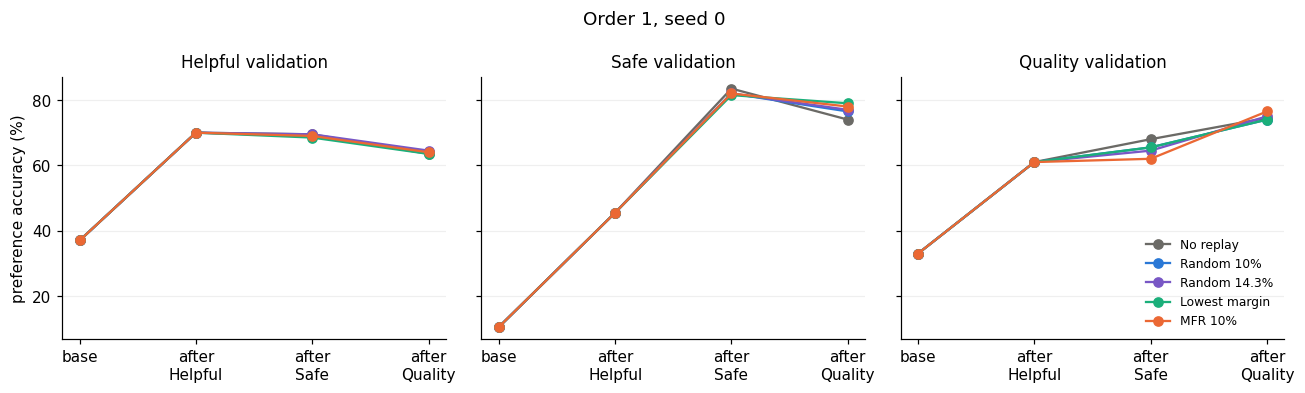

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)

for ax, dataset in zip(axes, ['helpful', 'safe', 'quality']):
    for method in methods:
        part = focus[(focus['method'] == method) & (focus['eval_set'] == dataset)].sort_values('stage')
        ax.plot(part['stage'], part['accuracy'], marker='o', color=COLOR[method], label=LABEL[method])
    ax.set_xticks([0, 1, 2, 3], ['base'] + [f'after\n{NAME[s]}' for s in stages])
    ax.set_title(f'{NAME[dataset]} validation')
    ax.grid(axis='y', alpha=0.2)

axes[0].set_ylabel('preference accuracy (%)')
axes[2].legend(fontsize=8)
fig.suptitle(f'Order {FOCUS_ORDER}, seed {FOCUS_SEED}')
fig.tight_layout()
plt.show()

## Figure 2 — how much was lost, by behavior

The same drop as a single number per behavior: accuracy right after it was learned, minus accuracy at the end. **Bars closer to zero are better.**

What to look for: MFR's bar shorter than random's on the same behavior. A gap of a point or two is inside the noise of one run — it only means something if it repeats across both seeds and both orders, which is what Figure 4 tests.

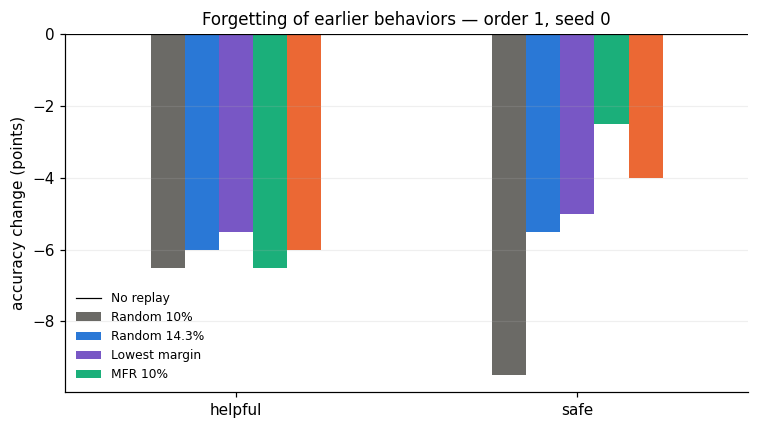

,run_name,order_id,method,seed,dataset,learned_at,right_after,at_end,change,margin_kept
0,v2_o1_lowest_margin_s0,1,lowest_margin,0,helpful,1,70.0,63.5,-6.5,168.24
1,v2_o1_lowest_margin_s0,1,lowest_margin,0,safe,2,81.5,79.0,-2.5,75.96
2,v2_o1_mfr_s0,1,mfr,0,helpful,1,70.0,64.0,-6.0,170.90
3,v2_o1_mfr_s0,1,mfr,0,safe,2,82.0,78.0,-4.0,75.52
4,v2_o1_none_s0,1,none,0,helpful,1,70.0,63.5,-6.5,169.57
5,v2_o1_none_s0,1,none,0,safe,2,83.5,74.0,-9.5,52.31
6,v2_o1_random_high_s0,1,random_high,0,helpful,1,70.0,64.5,-5.5,175.33
7,v2_o1_random_high_s0,1,random_high,0,safe,2,82.0,77.0,-5.0,71.50
8,v2_o1_random_s0,1,random,0,helpful,1,70.0,64.0,-6.0,173.41
9,v2_o1_random_s0,1,random,0,safe,2,82.0,76.5,-5.5,67.14


In [42]:
retention = mfr_analysis.retention_table(focus, score='accuracy')
retention['method'] = retention['method'].astype(str)

table = retention.pivot(index='dataset', columns='method', values='change')
table = table.reindex([d for d in stages[:-1] if d in table.index])
table = table[[m for m in ORDER if m in table.columns]]

ax = table.plot.bar(figsize=(7, 4), color=[COLOR[m] for m in table.columns], rot=0)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('accuracy change (points)')
ax.set_xlabel('')
ax.set_title(f'Forgetting of earlier behaviors — order {FOCUS_ORDER}, seed {FOCUS_SEED}')
ax.legend([LABEL[m] for m in table.columns], fontsize=8)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

display(retention.round(2))

## Figure 3 - retention against plasticity (the important one)

Every finished run as one point: forgetting on the x-axis, how well the final behavior was learned on the y-axis. **Bottom-left means it kept the old behaviors but learned the new one poorly; top-right means the opposite.** Good is up and to the left.

This is the figure that decides whether the project has a finding. If every method sits on one downward line, replay is only trading new learning for retention and MFR is nothing more than a more conservative setting. MFR earns its claim only by sitting **above** that line: same forgetting as random with more learning, or same learning with less forgetting.

`random_high` (14.3% replay) is on the plot for exactly this reason - it shows where the line goes when you simply spend more budget.

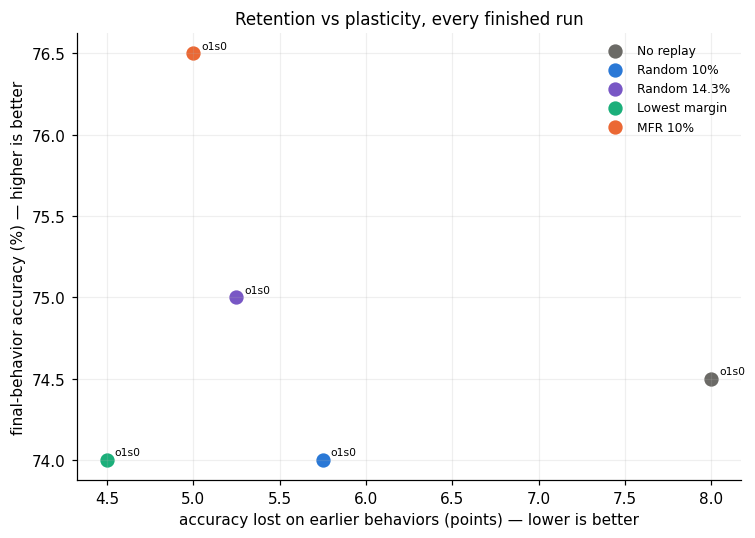

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))

for method in [m for m in ORDER if m in set(summary['method'])]:
    part = summary[summary['method'] == method]
    ax.scatter(-part['mean_retention_change'], part['final_new_stage_score'],
               s=70, color=COLOR[method], label=LABEL[method])
    for _, row in part.iterrows():
        ax.annotate(f"o{int(row.order_id)}s{int(row.seed)}",
                    (-row['mean_retention_change'], row['final_new_stage_score']),
                    xytext=(5, 3), textcoords='offset points', fontsize=7)

ax.set_xlabel('accuracy lost on earlier behaviors (points) — lower is better')
ax.set_ylabel('final-behavior accuracy (%) — higher is better')
ax.set_title('Retention vs plasticity, every finished run')
ax.grid(alpha=0.2)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Figure 4 — is the difference bigger than the noise?

Figures 2 and 3 show averages over 200 validation pairs, which move by a point or two for no reason at all. This one compares MFR against each baseline **pair by pair** and puts a bootstrap 95% interval on the difference.

Each row is one order/seed/behavior. Positive means MFR retained that behavior better. **A row only supports the claim if its whole interval sits to the right of zero**; intervals crossing zero are a null, however the dot is placed. Reporting the dots without the bars would be the single easiest way to overstate this project.

,order_id,seed,dataset,method,baseline,difference_points,ci_low,ci_high,n_pairs
0,1,0,helpful,mfr,lowest_margin,0.5,-1.5,2.5,200
1,1,0,safe,mfr,lowest_margin,-1.5,-4.0,0.5,200
2,1,0,helpful,mfr,random,0.0,-2.0,2.0,200
3,1,0,safe,mfr,random,1.5,-0.5,4.0,200
4,1,0,helpful,mfr,random_high,-0.5,-1.5,0.0,200
5,1,0,safe,mfr,random_high,1.0,-1.5,3.5,200


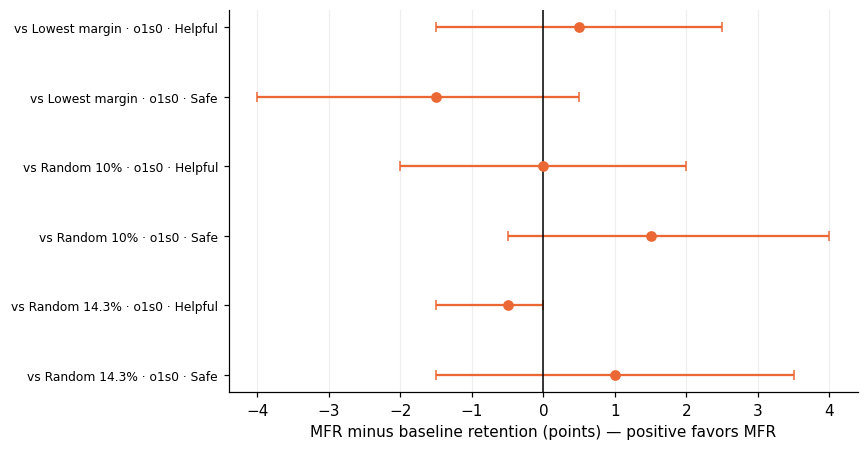

In [44]:
frames = []
for baseline in ['random', 'random_high', 'lowest_margin']:
    if baseline not in set(runs['method']):
        continue
    part = mfr_analysis.paired_retention_comparison(runs, baseline=baseline, margin='margin')
    if len(part):
        frames.append(part)

if not frames:
    print('need a matched mfr run and at least one baseline run')
else:
    paired = pd.concat(frames, ignore_index=True).sort_values(['baseline', 'order_id', 'seed', 'dataset'])
    paired = paired.reset_index(drop=True)
    display(paired.round(2))

    labels = [f"vs {LABEL[r.baseline]} · o{int(r.order_id)}s{int(r.seed)} · {NAME[r.dataset]}"
              for _, r in paired.iterrows()]
    y = np.arange(len(paired))

    fig, ax = plt.subplots(figsize=(8, 0.45 * len(paired) + 1.5))
    ax.errorbar(paired['difference_points'], y, fmt='o', color='#eb6834',
                xerr=[paired['difference_points'] - paired['ci_low'],
                      paired['ci_high'] - paired['difference_points']], capsize=3)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_yticks(y, labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('MFR minus baseline retention (points) — positive favors MFR')
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

## Table 3 — what MFR actually replayed

The honest-reporting table. `different_pairs` against `replayed_slots` says how much MFR repeated itself, and `from` says which old behavior supplied the slots.

Two things to watch, because either would undercut the story: if MFR cycles the same 50-odd pairs all stage, it is closer to fine-tuning on a fixed subset than to targeted replay; and if it draws far more from one behavior than random does, the advantage may be allocation rather than selection. We did not run a forced-equal-allocation control, so this table is how we report that limitation rather than hide it.

In [45]:
replay = mfr_analysis.replay_summary(focus)
if replay.empty:
    print('no replay logs in this cell (only the no-replay run?)')
else:
    shares = pd.json_normalize(replay['from']).fillna(0)
    replay = pd.concat([replay.drop(columns='from'), shares.add_prefix('from_')], axis=1)
    replay['slots_per_pair'] = (replay['replayed_slots'] / replay['different_pairs']).round(2)
    display(replay)

,run_name,method,stage,trained_on,replayed_slots,different_pairs,from_helpful,from_safe,slots_per_pair
0,v2_o1_lowest_margin_s0,lowest_margin,2,safe,222,132,222,0.0,1.68
1,v2_o1_lowest_margin_s0,lowest_margin,3,quality,222,73,105,117.0,3.04
2,v2_o1_mfr_s0,mfr,2,safe,222,138,222,0.0,1.61
3,v2_o1_mfr_s0,mfr,3,quality,222,108,74,148.0,2.06
4,v2_o1_random_high_s0,random_high,2,safe,333,254,333,0.0,1.31
5,v2_o1_random_high_s0,random_high,3,quality,333,261,161,172.0,1.28
6,v2_o1_random_s0,random,2,safe,222,179,222,0.0,1.24
7,v2_o1_random_s0,random,3,quality,222,185,104,118.0,1.20


## Table 4 — what it cost

Minutes per run, split into training and the re-scoring MFR needs to find the forgotten pairs, plus the total pairs each run trained on. Budget matching is on pair count — every method sees the same number of new pairs and takes the same number of optimizer steps — so the extra cost of MFR shows up here as scoring time, and has to be reported alongside any retention gain.

In [46]:
cost = mfr_analysis.cost_table(focus)
cost['method'] = cost['method'].astype(str)
cost = cost.set_index('method').reindex(methods).reset_index()
display(cost.round(2))

,method,run_name,order_id,seed,steps,examples,minutes,scoring_minutes,training_minutes
0,none,v2_o1_none_s0,1,0,336,6000,31.27,0.00,31.27
1,random,v2_o1_random_s0,1,0,336,6444,33.58,0.00,33.58
2,random_high,v2_o1_random_high_s0,1,0,336,6666,35.22,0.00,35.22
3,lowest_margin,v2_o1_lowest_margin_s0,1,0,336,6444,38.25,4.38,33.87
4,mfr,v2_o1_mfr_s0,1,0,336,6444,37.72,4.37,33.35


## What would count as a result

**A win for MFR.** In Figure 3 it sits above the line the other methods trace, not further along it. In Figure 4 the intervals clear zero, and they do it in both seeds and both orders, not in one cell. In Table 2 the new-stage gap stays inside the 2-point tolerance in every cell.

**A trade, not a win.** MFR forgets less, but its new-stage score falls by as much, so every method lands on one downward line in Figure 3. That means choosing *which* pairs to replay does nothing a more conservative setting would not also do.

**A null.** The intervals in Figure 4 straddle zero, or the sign flips between seeds or between orders.

The last two are still worth writing up. A budget-matched, seeded, pair-level comparison showing that which pairs you replay matters far less than how many is a real finding about replay for preference tuning - provided Table 3 is reported honestly, and provided we say plainly that quality is only ever the final stage and never a retention target.